In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


In [3]:
df = pd.read_excel("/content/war and fuel prices actual.xlsx")

In [3]:
df.head()

,Date,City,Fuel Type,Crude Oil Price USD,Brent Crude Price,USD INR Exchange_Rate,USD Strength Index,Inflation Rate,Fuel Demand Index,Transport Cost,Excise Duty,Refinery Cost,Forex Reserve Level,Season,Festival Season,War Risk Index,Sanction Severity,Global Supply Shock,Shipping Cost Index,Fuel price INR
0,2021-01-01,Pune,Diesel,86.29,93.41,82.85,107.11,NaN,105.68,14.72,25.78,10.65,560.94,Summer,Yes,2,0,0,101.99,207.54
1,2021-01-02,Chennai,Petrol,91.25,91.38,84.65,98.07,5.23,100.48,17.36,18.34,9.52,526.05,Summer,Yes,5,0,0,106.45,208.94
2,2021-01-03,Kolkata,Diesel,77.48,83.43,79.05,100.53,5.19,105.64,17.39,14.67,11.35,565.67,Winter,Yes,0,2,1,111.37,190.05
3,2021-01-04,Ahmedabad,Petrol,85.48,89.04,79.96,100.02,3.82,108.51,9.76,16.78,7.07,603.45,Monsoon,Yes,5,7,0,90.31,199.88
4,2021-01-05,Hyderabad,Diesel,84.61,87.38,83.14,101.49,7.20,106.45,10.21,27.05,14.75,504.42,Winter,Yes,0,7,1,98.24,222.13


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1040 entries, 0 to 1039
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   1040 non-null   object 
 1   City                   1040 non-null   object 
 2   Fuel Type              1040 non-null   object 
 3   Crude Oil Price USD    1014 non-null   float64
 4   Brent Crude Price      1040 non-null   float64
 5   USD INR Exchange_Rate  1013 non-null   float64
 6   USD Strength Index     1040 non-null   float64
 7   Inflation Rate         1014 non-null   float64
 8   Fuel Demand Index      1015 non-null   float64
 9   Transport Cost         1040 non-null   object 
 10  Excise Duty            1040 non-null   float64
 11  Refinery Cost          1040 non-null   float64
 12  Forex Reserve Level    1040 non-null   float64
 13  Season                 1040 non-null   object 
 14  Festival Season        1040 non-null   object 
 15  War 

In [5]:
df.isnull().sum()

,0
Date,0
City,0
Fuel Type,0
Crude Oil Price USD,26
Brent Crude Price,0
USD INR Exchange_Rate,27
USD Strength Index,0
Inflation Rate,26
Fuel Demand Index,25
Transport Cost,0


In [6]:
df = df.drop_duplicates()

In [7]:
df['City'] = df['City'].str.strip().str.title()

In [8]:
df['Transport Cost'] = pd.to_numeric(
    df['Transport Cost'],
    errors='coerce'
)

df['Shipping Cost Index'] = pd.to_numeric(
    df['Shipping Cost Index'],
    errors='coerce'
)

In [9]:
numeric_cols = [
    'Crude Oil Price USD',
    'Brent Crude Price',
    'USD INR Exchange_Rate',
    'USD Strength Index',
    'Inflation Rate',
    'Fuel Demand Index',
    'Transport Cost',
    'Excise Duty',
    'Refinery Cost',
    'Forex Reserve Level',
    'Shipping Cost Index'
]

imputer = SimpleImputer(strategy='mean')

df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

In [10]:
cat_cols = [
    'City',
    'Fuel Type',
    'Season',
    'Festival Season'
]

encoder = LabelEncoder()

for col in cat_cols:
    df[col] = encoder.fit_transform(df[col])

In [13]:
X = df.drop(columns=['Date', 'Fuel price INR'])

y = df['Fuel price INR']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
rf_model = RandomForestRegressor(
    n_estimators=250,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=250, random_state=42)

In [16]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

LinearRegression()

In [17]:
dt_model = DecisionTreeRegressor(
    random_state=42
)

dt_model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [18]:
rf_pred = rf_model.predict(X_test)

lr_pred = lr_model.predict(X_test)

dt_pred = dt_model.predict(X_test)

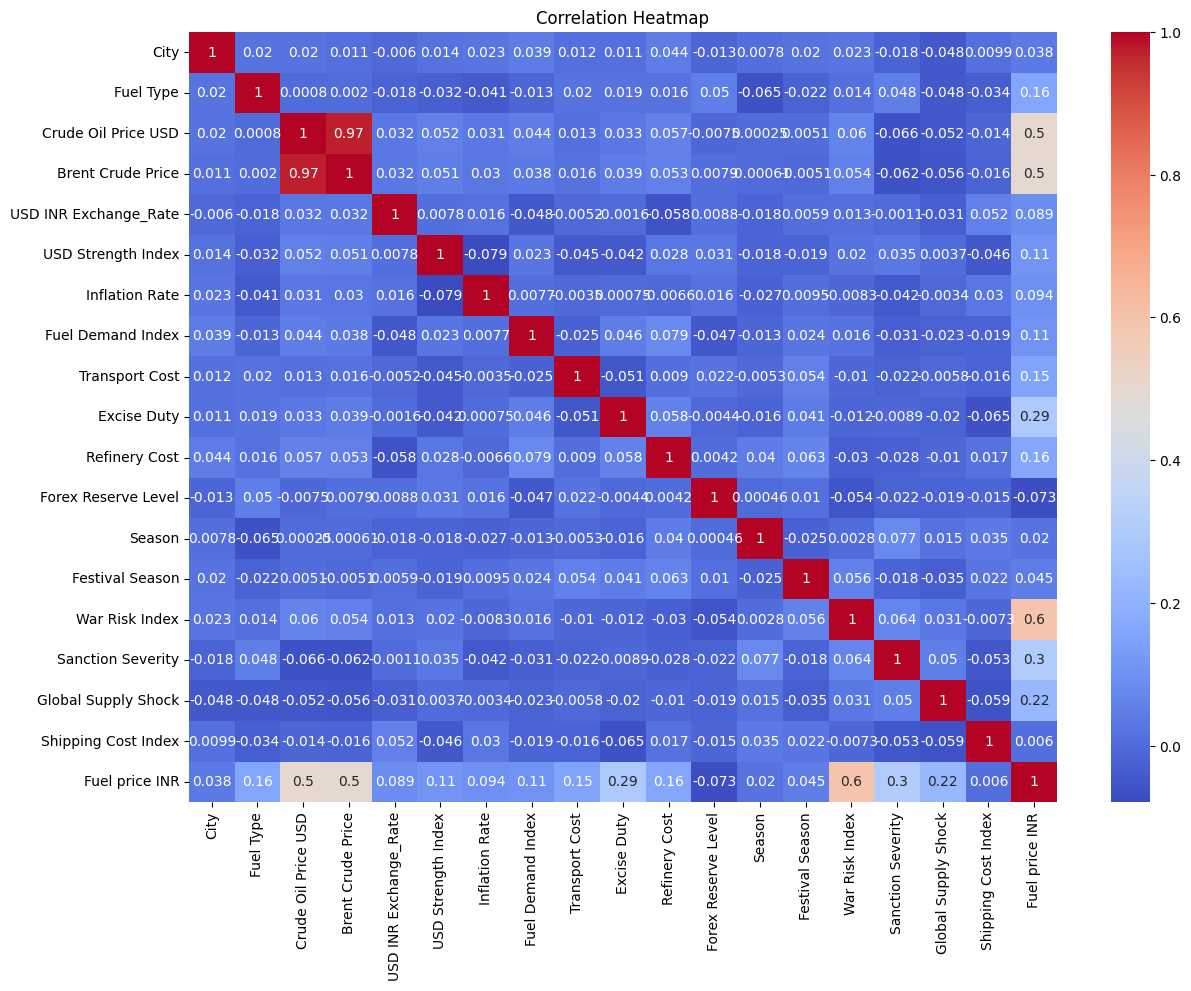

In [11]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

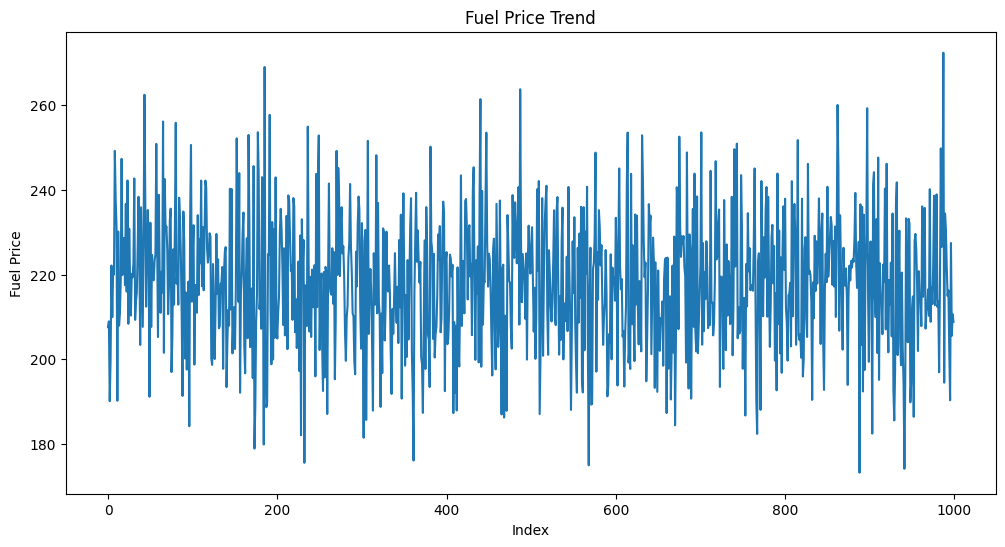

In [12]:
plt.figure(figsize=(12,6))

plt.plot(df['Fuel price INR'])

plt.title("Fuel Price Trend")

plt.xlabel("Index")
plt.ylabel("Fuel Price")

plt.show()

In [19]:
models = {
    "Random Forest": rf_pred,
    "Linear Regression": lr_pred,
    "Decision Tree": dt_pred
}

for name, pred in models.items():

    mae = mean_absolute_error(y_test, pred)

    rmse = np.sqrt(
        mean_squared_error(y_test, pred)
    )

    r2 = r2_score(y_test, pred)

    print("\n", name)
    print("------------------")

    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2 Score:", r2)


 Random Forest
------------------
MAE: 6.559732599999993
RMSE: 8.17888990809533
R2 Score: 0.7335089319486401

 Linear Regression
------------------
MAE: 4.083571282572541
RMSE: 5.24013132828183
R2 Score: 0.8906098354995646

 Decision Tree
------------------
MAE: 9.7819
RMSE: 12.289328256662364
R2 Score: 0.3983412709319655


In [20]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                  Feature  Importance
14         War Risk Index    0.303510
3       Brent Crude Price    0.146945
2     Crude Oil Price USD    0.137589
9             Excise Duty    0.095979
15      Sanction Severity    0.077737
8          Transport Cost    0.034111
10          Refinery Cost    0.033089
16    Global Supply Shock    0.031116
6          Inflation Rate    0.025516
7       Fuel Demand Index    0.022005
4   USD INR Exchange_Rate    0.019925
5      USD Strength Index    0.019895
11    Forex Reserve Level    0.016627
17    Shipping Cost Index    0.015059
0                    City    0.008019
1               Fuel Type    0.006273
12                 Season    0.004467
13        Festival Season    0.002139


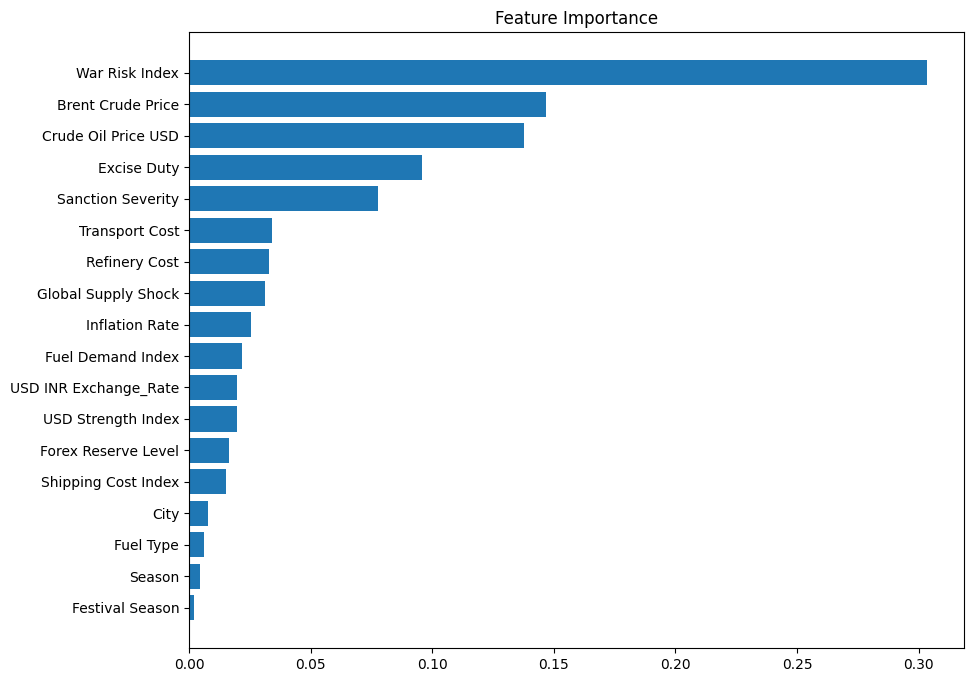

In [21]:
importance = importance.sort_values(
    by='Importance',
    ascending=True
)

plt.figure(figsize=(10,8))

plt.barh(
    importance['Feature'],
    importance['Importance']
)

plt.title("Feature Importance")

plt.show()

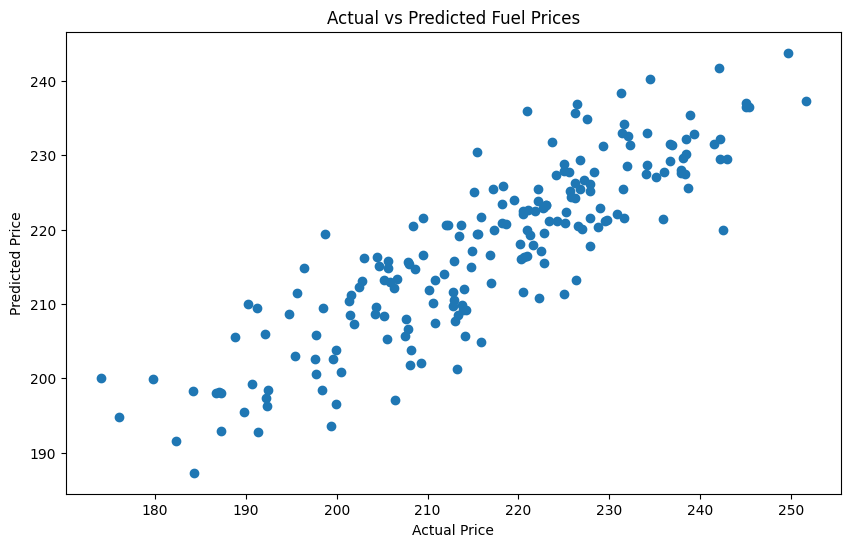

In [22]:
plt.figure(figsize=(10,6))

plt.scatter(y_test, rf_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Fuel Prices")

plt.show()

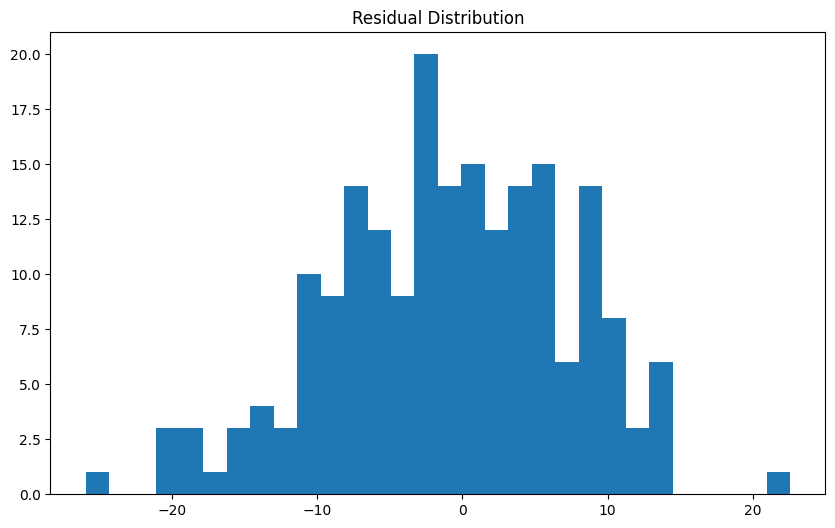

In [23]:
residuals = y_test - rf_pred

plt.figure(figsize=(10,6))

plt.hist(residuals, bins=30)

plt.title("Residual Distribution")

plt.show()

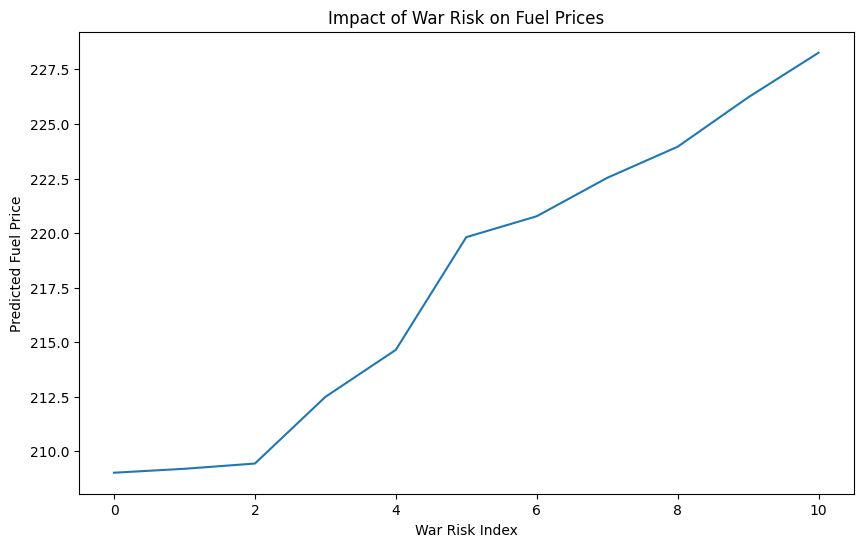

In [24]:
sample = X.iloc[[0]].copy()

predictions = []

for war in range(0,11):

    sample['War Risk Index'] = war

    pred = rf_model.predict(sample)

    predictions.append(pred[0])

plt.figure(figsize=(10,6))

plt.plot(range(0,11), predictions)

plt.xlabel("War Risk Index")
plt.ylabel("Predicted Fuel Price")

plt.title("Impact of War Risk on Fuel Prices")

plt.show()

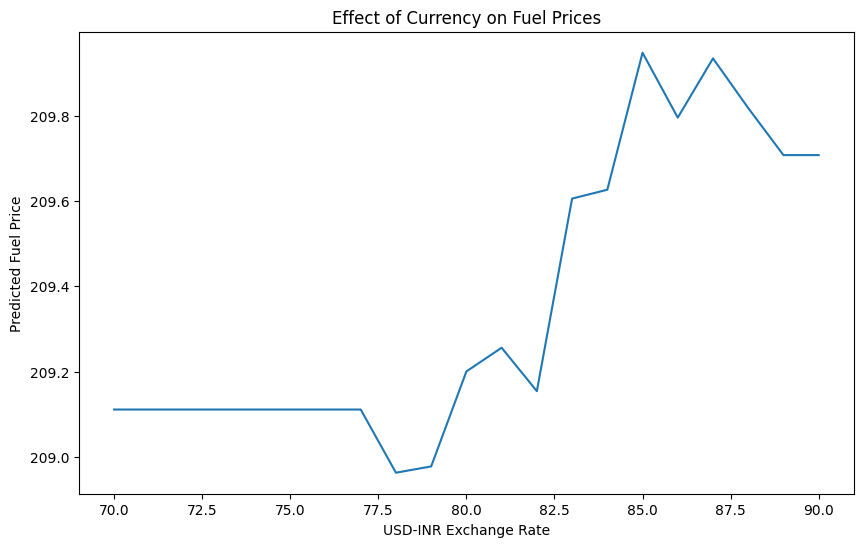

In [25]:
sample = X.iloc[[0]].copy()

currency_preds = []

rates = range(70, 91)

for rate in rates:

    sample['USD INR Exchange_Rate'] = rate

    pred = rf_model.predict(sample)

    currency_preds.append(pred[0])

plt.figure(figsize=(10,6))

plt.plot(rates, currency_preds)

plt.xlabel("USD-INR Exchange Rate")
plt.ylabel("Predicted Fuel Price")

plt.title("Effect of Currency on Fuel Prices")

plt.show()

In [26]:
sample_data = pd.DataFrame({

    'City':[0],
    'Fuel Type':[1],
    'Crude Oil Price USD':[100],
    'Brent Crude Price':[104],
    'USD INR Exchange_Rate':[86],
    'USD Strength Index':[108],
    'Inflation Rate':[7],
    'Fuel Demand Index':[115],
    'Transport Cost':[18],
    'Excise Duty':[25],
    'Refinery Cost':[10],
    'Forex Reserve Level':[540],
    'Season':[2],
    'Festival Season':[1],
    'War Risk Index':[8],
    'Sanction Severity':[7],
    'Global Supply Shock':[1],
    'Shipping Cost Index':[130]
})

future_prediction = rf_model.predict(sample_data)

print(
    "Predicted Future Fuel Price:",
    future_prediction[0]
)

Predicted Future Fuel Price: 245.31307999999999
